# Toy Squares Base DP Evaluation

This notebook evaluates a trained base Diffusion Policy checkpoint on **Early Decision** and **Late Decision** toy scenarios (5 rollouts each), and includes a fixed-action environment sanity check GIF.

In [1]:
import h5py

# Open the file in read-only mode
with h5py.File('../data/toy_squares/train/data.hdf5', 'r') as f:
    # Print the top-level keys
    print(len(list(f['data'].keys())))

10000


In [2]:
import copy
import json
import os
import pickle
import random
import socket
import subprocess
from datetime import datetime
from itertools import permutations
from pathlib import Path

import imageio
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, Image, display
from matplotlib.collections import LineCollection
from matplotlib.patches import RegularPolygon

import robomimic
import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.torch_utils as TorchUtils

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


hostname: mk-c
pid: 406509
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-09d77f1f-8992-15cc-7b76-e48a47442fcd)


In [4]:
# Set this to your trained base DP checkpoint
DP_CKPT_PATH = "/scratch/gilbreth/zoellner/diffusion_runs/toy_squares_dp/20260421005349/models/model_epoch_2_data_success_0.0.pth"
DP_CKPT_PATH = "/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth"

assert Path(DP_CKPT_PATH).exists(), f"Checkpoint not found: {DP_CKPT_PATH}"

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=DP_CKPT_PATH, device=device, verbose=False)
env, _ = FileUtils.env_from_checkpoint(ckpt_dict=ckpt_dict, render=False, render_offscreen=True, verbose=False)

print("Loaded policy and environment successfully.")
print("Environment type:", type(env))


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.710221e+07
Created environment with name TouchCube
Action size is 2
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
Loaded policy and environment successfully.
Environment type: <class 'robomimic.envs.wrappers.FrameStackWrapper'>


/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:20: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float32. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:25: UserWarning: WARN: It seems a Box observation space is an image but the upper and lower bounds are not in [

In [7]:
OUTPUT_ROOT = Path("/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/base_DP")

def jiggle(deterministic=False, scale=1.0):
    if deterministic:
        return 0.0
    return scale * (2.0 * (np.random.random() - 0.5))

def early_decision_cube_setup(deterministic=False):
    cube_1 = [128 + 30 * jiggle(deterministic), 128 + 30 * jiggle(deterministic)]
    cube_2 = [128 + 30 * jiggle(deterministic), 384 + 30 * jiggle(deterministic)]
    cube_4 = [384 + 30 * jiggle(deterministic), 128 + 30 * jiggle(deterministic)]
    cube_3 = [384 + 30 * jiggle(deterministic), 384 + 30 * jiggle(deterministic)]
    agent = [255 + 60 * jiggle(deterministic), 255 + 60 * jiggle(deterministic)]

    loc_list = [agent, cube_1, cube_2, cube_3, cube_4]
    rand_rots = np.random.rand(4) * 2 * np.pi - np.pi
    loc_list.append(rand_rots)
    return np.concatenate(loc_list)

def late_decision_cube_setup(deterministic=False):
    cube_1 = [100, 340 + 30 * jiggle(deterministic)]
    cube_2 = [100, 420 + 30 * jiggle(deterministic)]
    cube_3 = [150 + 30 * jiggle(deterministic), 460]
    cube_4 = [230 + 30 * jiggle(deterministic), 460]
    agent = [420 + 30 * jiggle(deterministic), 120 + 30 * jiggle(deterministic)]

    loc_list = [agent, cube_1, cube_2, cube_3, cube_4]
    rand_rots = np.random.rand(4) * 2 * np.pi - np.pi
    loc_list.append(rand_rots)
    return np.concatenate(loc_list)

def _checkpoint_tag(path_str):
    return Path(path_str).name

def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)

def _render_frame(env, height=512, width=512, camera_name="agentview"):
    try:
        return env.render(mode="rgb_array", height=height, width=width, camera_name=camera_name)
    except TypeError:
        return env.render(mode="rgb_array", height=height, width=width)

def _obs_low_level_snapshot(obs):
    snapshot = {}
    for key in ["states", "agent_pos"]:
        if key in obs:
            snapshot[key] = _to_numpy(obs[key]).copy()
    return snapshot

def _stack_or_object(values):
    values = list(values)
    if not values:
        return np.array([])
    try:
        return np.stack(values)
    except Exception:
        return np.array(values, dtype=object)

def run_rollout(policy, env, setup_fn, horizon=200, render=True):
    setup_state = _to_numpy(setup_fn(deterministic=False)).copy()
    obs = env.reset_to(setup_state)
    policy.start_episode()

    total_reward = 0.0
    success = False
    steps = 0

    full_obs = [copy.deepcopy(obs)]
    low_level_obs = [_obs_low_level_snapshot(obs)]
    step_records = []
    frames = []
    if render:
        frames.append(_render_frame(env))

    for t in range(horizon):
        action = _to_numpy(policy(ob=obs)).copy()
        next_obs, reward, done, info = env.step(action)
        reward_value = float(reward)
        total_reward += reward_value
        steps = t + 1
        step_success = bool(info.get("success", False) or reward_value > 0)
        success = success or step_success
        step_record = {
            "t": t,
            "action": action,
            "reward": reward_value,
            "done": bool(done),
            "success": step_success,
            "state": _obs_low_level_snapshot(obs),
        }
        step_records.append(step_record)
        full_obs.append(copy.deepcopy(next_obs))
        low_level_obs.append(_obs_low_level_snapshot(next_obs))
        obs = next_obs
        if render:
            frames.append(_render_frame(env))
        if done or success:
            break

    return {
        "success": float(success),
        "steps": steps,
        "return": total_reward,
        "setup_state": setup_state,
        "full_obs": full_obs,
        "low_level_obs": low_level_obs,
        "step_records": step_records,
        "frames": frames,
    }

def _save_rollout_artifacts(run_dir, rollout):
    run_dir.mkdir(parents=True, exist_ok=True)
    with open(run_dir / "rollout_summary.json", "w", encoding="utf-8") as f:
        json.dump({"success": rollout["success"], "steps": rollout["steps"], "return": rollout["return"]}, f, indent=2)

    with open(run_dir / "full_obs.pkl", "wb") as f:
        pickle.dump(rollout["full_obs"], f)

    with open(run_dir / "step_records.pkl", "wb") as f:
        pickle.dump(rollout["step_records"], f)

    np.savez_compressed(
        run_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in rollout["low_level_obs"]]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in rollout["low_level_obs"]]),
    )
    np.save(run_dir / "setup_state.npy", rollout["setup_state"])

    if rollout["frames"]:
        imageio.mimsave(run_dir / "rollout.gif", rollout["frames"], duration=0.12)

def evaluate_scenario(policy, env, setup_fn, scenario_name, n_rollouts=100, horizon=200):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    policy_path_tag = _checkpoint_tag(DP_CKPT_PATH)
    scenario_dir = OUTPUT_ROOT / policy_path_tag / f"n{n_rollouts}_{scenario_name}_h{horizon}_{timestamp}"
    scenario_dir.mkdir(parents=True, exist_ok=True)

    records = []
    all_frames = []

    for rollout_idx in range(n_rollouts):
        rollout = run_rollout(policy, env, setup_fn, horizon=horizon, render=True)
        run_dir = scenario_dir / f"rollout_{rollout_idx:03d}"
        _save_rollout_artifacts(run_dir, rollout)
        records.append({"rollout_idx": rollout_idx, "success": rollout["success"], "steps": rollout["steps"], "return": rollout["return"], "run_dir": str(run_dir)})
        all_frames.extend(rollout["frames"] or [])
        if rollout["frames"]:
            separator = np.zeros_like(rollout["frames"][0])
            all_frames.extend([separator, separator, separator])

    success_rate = float(np.mean([r["success"] for r in records])) if records else 0.0
    avg_steps = float(np.mean([r["steps"] for r in records])) if records else 0.0
    avg_return = float(np.mean([r["return"] for r in records])) if records else 0.0

    summary = {
        "scenario_name": scenario_name,
        "n_rollouts": n_rollouts,
        "horizon": horizon,
        "success_rate": success_rate,
        "avg_steps": avg_steps,
        "avg_return": avg_return,
        "policy_path": DP_CKPT_PATH,
        "scenario_dir": str(scenario_dir),
        "records": records,
    }

    with open(scenario_dir / "scenario_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    if all_frames:
        imageio.mimsave(scenario_dir / "all_runs.gif", all_frames, duration=0.12)

    return summary

In [11]:
env.reset()
early_results = evaluate_scenario(policy, env, early_decision_cube_setup, "early_decision", n_rollouts=50, horizon=200)
env.reset()
late_results = evaluate_scenario(policy, env, late_decision_cube_setup, "late_decision", n_rollouts=50, horizon=200)

print("Early Decision:", {k: v for k, v in early_results.items() if k != "records"})
print("Late Decision:", {k: v for k, v in late_results.items() if k != "records"})

Early Decision: {'scenario_name': 'early_decision', 'n_rollouts': 50, 'horizon': 200, 'success_rate': 1.0, 'avg_steps': 66.08, 'avg_return': 1.0, 'policy_path': '/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth', 'scenario_dir': '/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/base_DP/model_epoch_320_best_validation_0.005075077305082232.pth/n50_early_decision_h200_20260423_185359'}
Late Decision: {'scenario_name': 'late_decision', 'n_rollouts': 50, 'horizon': 200, 'success_rate': 0.98, 'avg_steps': 95.62, 'avg_return': 0.98, 'policy_path': '/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth', 'scenario_dir': '/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/base_DP/model_epoch_320_best_validation_0.005075077305082232.pth/n50_late_decision_h200_20260423_185423'}


In [14]:
early_gif = Path(early_results["scenario_dir"]) / "all_runs.gif"
late_gif = Path(late_results["scenario_dir"]) / "all_runs.gif"

def _gif_widget(label, gif_path):
    image = widgets.Image(value=Path(gif_path).read_bytes(), format="gif", layout=widgets.Layout(width="180px"))
    caption = widgets.HTML(f"<b>{label}</b><br>{gif_path}")
    return widgets.VBox([caption, image], layout=widgets.Layout(width="200px", align_items="center"))

display(
    widgets.HBox(
        [
            _gif_widget("Early Decision", early_gif),
            _gif_widget("Late Decision", late_gif),
        ],
        layout=widgets.Layout(gap="12px"),
    )
)

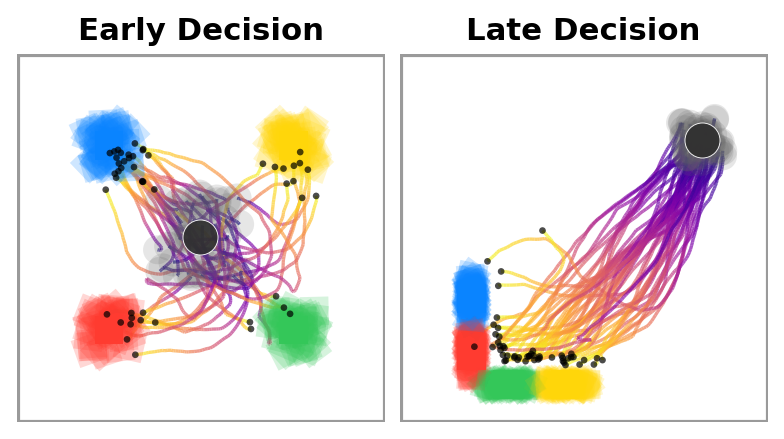

Saved overlay plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/base_DP/model_epoch_320_best_validation_0.005075077305082232.pth/n50_late_decision_h200_20260423_185423/trajectory_overlay_20260423_185506.png


In [13]:
def _load_rollout_trace(run_dir):
    with np.load(Path(run_dir) / "low_level_obs.npz", allow_pickle=True) as data:
        states = np.asarray(data["states"])

        agent_pos = np.asarray(data["agent_pos"])

    if states.dtype == object:
        states = np.stack([np.asarray(item, dtype=float) for item in states])
    else:
        states = states.astype(float)
    if agent_pos.dtype == object:
        agent_pos = np.stack([np.asarray(item, dtype=float) for item in agent_pos])
    else:
        agent_pos = agent_pos.astype(float)
    return states, agent_pos

def _canonical_layout(setup_fn):
    layout = np.asarray(setup_fn(deterministic=True), dtype=float)
    agent_pos = layout[:2] / 256.0 - 1.0
    block_positions = layout[2:10].reshape(4, 2) / 256.0 - 1.0
    return agent_pos, block_positions

def _collapse_latest_frame(value):
    array = np.asarray(value, dtype=float)
    if array.ndim <= 1:
        return array
    return array[-1]

def _trajectory_segments(points):
    points = np.asarray(points, dtype=float)
    return np.stack([points[:-1], points[1:]], axis=1)

def _flip_y(points):
    arr = np.asarray(points, dtype=float).copy()
    arr[..., 1] *= -1.0
    return arr

def _load_setup_layout(run_dir):
    setup_state = np.load(Path(run_dir) / "setup_state.npy")
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    return blocks, angles

def _draw_blocks(ax, centers, angles, colors, radius=0.07, alpha=1.0, zorder=3):
    for center, angle, color in zip(centers, angles, colors):
        patch = RegularPolygon(
            (center[0], center[1]),
            numVertices=4,
            radius=radius,
            orientation=angle + np.pi / 4.0,
            facecolor=color,
            edgecolor="none",
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(patch)

def _match_blocks_to_canonical(blocks, canonical_blocks):
    blocks = np.asarray(blocks, dtype=float)
    canonical_blocks = np.asarray(canonical_blocks, dtype=float)
    best_perm = None
    best_cost = np.inf
    for perm in permutations(range(4)):
        candidate = blocks[list(perm)]
        cost = np.sum((candidate - canonical_blocks) ** 2)
        if cost < best_cost:
            best_cost = cost
            best_perm = perm
    return blocks[list(best_perm)]

def _plot_rollouts(ax, results, setup_fn, title):
    palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    canonical_agent_raw, canonical_blocks_raw = _canonical_layout(setup_fn)
    canonical_agent = _flip_y(canonical_agent_raw)
    canonical_blocks = _flip_y(canonical_blocks_raw)
    canonical_angles = np.zeros(4)

    for record in results["records"]:
        states, agent_pos = _load_rollout_trace(record["run_dir"])

        setup_blocks_raw, setup_angles_raw = _load_setup_layout(record["run_dir"])

        start_blocks = _match_blocks_to_canonical(setup_blocks_raw, canonical_blocks_raw)
        permuted_angles = np.zeros(4)
        for idx, block in enumerate(start_blocks):
            distances = np.sum((setup_blocks_raw - block) ** 2, axis=1)
            permuted_angles[idx] = setup_angles_raw[int(np.argmin(distances))]
        start_blocks = _flip_y(start_blocks)
        start_angles = -permuted_angles
        start_agent = _flip_y(_collapse_latest_frame(agent_pos[0]))
        trajectory = np.stack([_collapse_latest_frame(step) for step in agent_pos], axis=0)
        trajectory = _flip_y(trajectory)

        if len(trajectory) > 1:
            segments = _trajectory_segments(trajectory)
            line = LineCollection(
                segments,
                cmap="plasma",
                norm=plt.Normalize(0.0, 1.0),
                linewidths=1.4,
                alpha=0.68,
                zorder=2,
            )
            line.set_array(np.linspace(0.0, 1.0, len(segments)))
            ax.add_collection(line)

        _draw_blocks(ax, start_blocks, start_angles, palette, radius=0.11, alpha=0.2, zorder=3)
        ax.scatter(
            [start_agent[0]],
            [start_agent[1]],
            s=150,
            marker="o",
            c="#666666",
            alpha=0.16,
            edgecolors="none",
            zorder=3,
        )
        ax.scatter(
            [trajectory[-1, 0]],
            [trajectory[-1, 1]],
            s=8,
            marker="o",
            c="#000000",
            alpha=0.7,
            edgecolors="none",
            linewidths=0.0,
            zorder=6,
        )

    _draw_blocks(ax, canonical_blocks, canonical_angles, palette, radius=0.11, alpha=0.95, zorder=4)
    ax.scatter(
        [canonical_agent[0]],
        [canonical_agent[1]],
        s=220,
        marker="o",
        c="#2f2f2f",
        alpha=0.92,
        edgecolors="white",
        linewidths=0.4,
        zorder=5,
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=2.2, zorder=10)
    ax.add_patch(frame)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
comparison_dir = Path(late_results["scenario_dir"])

comparison_dir.mkdir(parents=True, exist_ok=True)
comparison_path = comparison_dir / f"trajectory_overlay_{timestamp}.png"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4.5, 3.8), dpi=170, constrained_layout=True)
_plot_rollouts(ax1, early_results, early_decision_cube_setup, "Early Decision")
_plot_rollouts(ax2, late_results, late_decision_cube_setup, "Late Decision")
fig.savefig(comparison_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(f"Saved overlay plot to {comparison_path}")